In [ ]:
!git clone https://github.com/emillia-q/audio-violence-detection-tinyml.git
%cd audio-violence-detection-tinyml

from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/audio-violence-detection-tflite/data.tar.gz" .
!tar -xzvf data.tar.gz

# Configuration and Imports
Importing necessary libraries.

In [2]:
# Config
import json
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import random
from pathlib import Path
from datetime import datetime
from typing import Tuple

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Scripts
from scripts.splitting import get_source_name, grouped_balanced_split

# Metrics
import joblib
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

### Set Random Seeds for Reproducibility

Setting random seeds ensures that experiments are repeatable. Crucial for comparing model performance across different runs. Set seeds for Python's built-in `random` module, `numpy`, and `tensorflow`.

In [3]:
# Set random seed for Python's built-in random module
random.seed(42)

# Set random seed for NumPy
np.random.seed(42)

# Set random seed for TensorFlow
tf.random.set_seed(42)

# Optionally, for deterministic behavior on GPU (might slightly slow down training)
tf.config.experimental.set_memory_growth(tf.config.experimental.list_physical_devices('GPU')[0], True)


# Feature Extraction Function Definitions
Defining functions to extract MFCC features and crawl the directory structure.

In [4]:
def extract_features(file_path: str | Path, n_mfcc=13) -> np.ndarray:
    """
    Returns full MFCC Matrix (time x features).
    """
    y, sr = librosa.load(str(file_path), sr=16000)

    # SANITY: exactly 32000 samples (2 sec)
    # If y is to short - add zeroes, if too long - truncate
    y = librosa.util.fix_length(y, size=32000)

    # Calculate MFCC, 2s & sr=16000 with domain params gives around 63 frames
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Preparation for CNN (time, features, channel)
    return mfcc.T[:,:,np.newaxis].astype(np.float32)

def load_dataset(processed_path: str | Path) -> Tuple[np.ndarray, np.ndarray, dict, list]:
    """
    Crawls the processed data directory to extract features from all samples
      while automatically generating a numeric label mapping based on folder names.
    """
    X, y, file_paths = [], [], []
    label_to_name = {}
    processed_dir = Path(processed_path)

    for category_dir in processed_dir.iterdir():
        if not category_dir.is_dir():
            continue

        try:
            label = int(category_dir.name.split('_')[0])
            clean_name = category_dir.name.split('_', 1)[1].replace('_', ' ').title()
            label_to_name[label] = clean_name
        except (ValueError, IndexError):
            continue

        for file_path in category_dir.glob("*.wav"):
            features = extract_features(file_path=file_path)
            X.append(features)
            y.append(label)
            file_paths.append(str(file_path))

    return np.array(X), np.array(y), label_to_name, file_paths

# Prepare Dataset

`load_dataset` runs MFCC extraction for every segment in `data/processed/`.

The split is **source-level and segment-balanced per class**: every original recording goes entirely to one of `train` / `val` / `test` (no leakage - `Leak check` must be all zeros) and each class is split into roughly **64% / 16% / 20%** of its **segments**, not just of its sources. This is necessary because source segment counts vary widely (one long ambient recording vs many short violence shouts), so plain source-level stratification leaves the per-class segment proportions in val/test very far from the train mix.

In [5]:
# Load data
DATA_PATH = Path('data/processed')
X, y, target_map, all_paths = load_dataset(DATA_PATH)
target_names = [target_map[i] for i in sorted(target_map.keys())]

meta = pd.DataFrame({
    "path": all_paths,
    "label": y,
    "source": [get_source_name(p) for p in all_paths]
})

train_sources, val_sources, test_sources = grouped_balanced_split(
    meta, val_size=0.16, test_size=0.20, random_state=42
)

# Filter data
train_mask = meta["source"].isin(train_sources).values
val_mask = meta["source"].isin(val_sources).values
test_mask = meta["source"].isin(test_sources).values

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train shape: {X_train.shape}") # Should be (N, 63, 13, 1)

Train shape: (16666, 63, 13, 1)


# CNN Model Architecture

In [6]:
def build_model(input_shape: Tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    """
    Creates CNN architecture optimized for TinyML.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # First splot layer (detects simple edges on sound)
        layers.Conv2D(16,(3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Second splot layer (more complex formulas)
        layers.Conv2D(32,(3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5), # Prevents overfitting
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(input_shape=X_train.shape[1:], num_classes=len(target_map))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 63, 13, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 6, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 6, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        92,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,219 (379.76 KB)

 Trainable params: 97,219 (379.76 KB)

 Non-trainable params: 0 (0.00 B)

# Training and Evaluation

Epoch 1/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5227 - loss: 1.2331 - val_accuracy: 0.5314 - val_loss: 0.8804
Epoch 2/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6588 - loss: 0.7291 - val_accuracy: 0.6428 - val_loss: 0.7159
Epoch 3/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7456 - loss: 0.6048 - val_accuracy: 0.6567 - val_loss: 0.7152
Epoch 4/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7899 - loss: 0.5245 - val_accuracy: 0.7140 - val_loss: 0.6887
Epoch 5/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8262 - loss: 0.4484 - val_accuracy: 0.6874 - val_loss: 0.7832
Epoch 6/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8735 - loss: 0.3585 - val_accuracy: 0.6665 - val_loss: 1.0655
Epoch 7/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8942 - loss: 0.3015 - val_accuracy: 0.7198 - val_loss: 0.9653
Epoch 8/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9064 - loss: 0.2627 - val_accuracy: 0

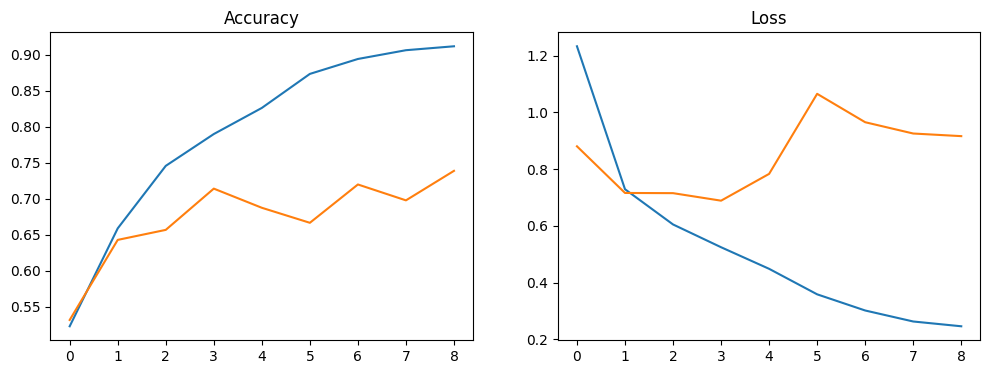

In [7]:
# Stops training when models has stopped correcting
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# Charts
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='train'); plt.plot(history.history['val_accuracy'], label='val'); plt.title('Accuracy')
plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='train'); plt.plot(history.history['val_loss'], label='val'); plt.title('Loss')
plt.show()

# Final evaluation on held-out test
Metrics match the RF notebook: accuracy, balanced accuracy, macro/weighted F1, and a full classification report. Predictions use the trained Keras model (same weights as exported TFLite).

In [8]:
y_test_proba = model.predict(X_test, batch_size=32, verbose=0)
y_test_pred = np.argmax(y_test_proba, axis=1)

acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average="macro")
weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")

print(f"Accuracy:          {acc * 100:.2f}%")
print(f"Balanced accuracy: {balanced_acc * 100:.2f}%")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")
print(classification_report(y_test, y_test_pred, target_names=target_names))

y_val_pred = np.argmax(model.predict(X_val, batch_size=32, verbose=0), axis=1)
BEST_VAL_METRICS = {
    "accuracy": float(accuracy_score(y_val, y_val_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_val, y_val_pred)),
    "macro_f1": float(f1_score(y_val, y_val_pred, average="macro")),
    "weighted_f1": float(f1_score(y_val, y_val_pred, average="weighted")),
}

TRAINING_CONFIG = {
    "epochs_max": 50,
    "batch_size": 32,
    "early_stopping_patience": 5,
    "early_stopping_monitor": "val_loss",
    "restore_best_weights": True,
    "epochs_trained": len(history.history["loss"]),
}

Accuracy:          75.60%
Balanced accuracy: 76.01%
Macro F1:          0.7540
Weighted F1:       0.7539
              precision    recall  f1-score   support

     Ambient       0.66      0.81      0.73      1576
      Speech       0.76      0.61      0.68      1855
    Violence       0.85      0.86      0.86      1779

    accuracy                           0.76      5210
   macro avg       0.76      0.76      0.75      5210
weighted avg       0.76      0.76      0.75      5210



# Versioning and serialization

Same layout as `notebooks/rf/train_model.ipynb`: versioned folders under `models/tflite` and `reports/tflite`, confusion matrix PNG, `classification_errors.csv`, `metrics.json`, and `latest_version_tflite.txt` at the **repository root** (valid after `%cd audio-violence-detection-tinyml` in Colab).

Saved artifact at '/tmp/tmpkavz6_fq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 63, 13, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136350967388816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136350967393808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136350964757328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136350964757712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136350964746384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136350964752336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136350967393616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136350964744656: TensorSpec(shape=(), dtype=tf.resource, name=None)


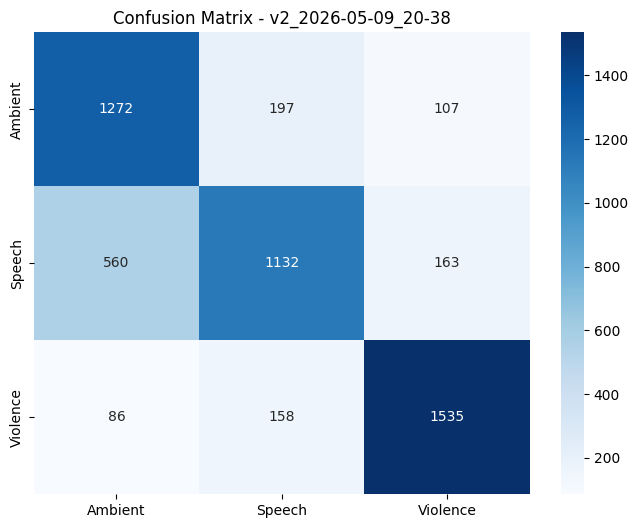

In [10]:
def get_next_version(base_path: Path) -> str:
    base_path.mkdir(parents=True, exist_ok=True)
    existing = [d.name for d in base_path.iterdir() if d.is_dir() and d.name.startswith("v")]
    version_numbers = []
    for v in existing:
        try:
            num = int(v.split("_")[0][1:])
            version_numbers.append(num)
        except ValueError:
            continue

    next_num = max(version_numbers, default=0) + 1
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")

    return f"v{next_num}_{timestamp}"


# Repo root in Colab: .../audio-violence-detection-tinyml (after %cd in first cell)
BASE_DIR_MODEL = Path("models/tflite")
BASE_DIR_REPORT = Path("reports/tflite")
CURRENT_VERSION = get_next_version(BASE_DIR_MODEL)
MODEL_PATH = BASE_DIR_MODEL / CURRENT_VERSION
REPORT_PATH = BASE_DIR_REPORT / CURRENT_VERSION
MODEL_PATH.mkdir(parents=True, exist_ok=True)
REPORT_PATH.mkdir(parents=True, exist_ok=True)

model.save(MODEL_PATH / "cnn_model.keras")
joblib.dump(target_map, MODEL_PATH / "target_map.pkl")

# Directly convert the Keras model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_bytes = converter.convert()
(MODEL_PATH / "model.tflite").write_bytes(tflite_bytes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title(f"Confusion Matrix - {CURRENT_VERSION}")
plt.savefig(REPORT_PATH / "confusion_matrix.png")
plt.show()

analysis_df = pd.DataFrame(
    {
        "file_path": np.array(all_paths)[test_mask],
        "true_label": [target_map[i] for i in y_test],
        "predicted_label": [target_map[i] for i in y_test_pred],
    }
)
errors = analysis_df[analysis_df["true_label"] != analysis_df["predicted_label"]]
errors.to_csv(REPORT_PATH / "classification_errors.csv", index=False)

report_dict = classification_report(
    y_test, y_test_pred, target_names=target_names, output_dict=True, zero_division=0
)
metrics_payload = {
    "version": CURRENT_VERSION,
    "model": "cnn_tflite",
    "training_config": TRAINING_CONFIG,
    "val_metrics": BEST_VAL_METRICS,
    "n_train_segments": int(len(y_train)),
    "n_val_segments": int(len(y_val)),
    "n_test_segments": int(len(y_test)),
    "train_class_proportions": pd.Series(y_train).value_counts(normalize=True).sort_index().round(4).to_dict(),
    "val_class_proportions": pd.Series(y_val).value_counts(normalize=True).sort_index().round(4).to_dict(),
    "test_class_proportions": pd.Series(y_test).value_counts(normalize=True).sort_index().round(4).to_dict(),
    "test_metrics": {
        "accuracy": float(acc),
        "balanced_accuracy": float(balanced_acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
    },
    "classification_report_test": report_dict,
}
with open(REPORT_PATH / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

with open("latest_version_tflite.txt", "w", encoding="utf-8") as f:
    f.write(CURRENT_VERSION)